#  Data Science HW7

 * 作業繳交期限 : 2021/05/17 12:00</br>
 * 上傳作業之ipynb檔案，檔名固定為[學號-姓名.ipynb]，例：107379999-王大明.ipynb，未符合格式者視同未交作業</br>
 * 作業完成後至Google表單上傳檔案(請用學校帳號繳交) </br>https://forms.gle/9y4m28sPMn3ysAsT6

---

In [1]:
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn.svm import SVC,SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import classification_report
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 第一大題 

 - 使用乳癌資料集
 - 使用SVC : Support Vector Classification方法 
 - Target : malignant, benign
 - 資料切分 train: test = 7:3 , random_state = 888
 

### * 載入套件與資料集








In [2]:
#取得Scikit Learn上的乳癌資料集
breast = datasets.load_breast_cancer()
breast

{'DESCR': '.. _breast_cancer_dataset:\n\nBreast cancer wisconsin (diagnostic) dataset\n--------------------------------------------\n\n**Data Set Characteristics:**\n\n    :Number of Instances: 569\n\n    :Number of Attributes: 30 numeric, predictive attributes and the class\n\n    :Attribute Information:\n        - radius (mean of distances from center to points on the perimeter)\n        - texture (standard deviation of gray-scale values)\n        - perimeter\n        - area\n        - smoothness (local variation in radius lengths)\n        - compactness (perimeter^2 / area - 1.0)\n        - concavity (severity of concave portions of the contour)\n        - concave points (number of concave portions of the contour)\n        - symmetry \n        - fractal dimension ("coastline approximation" - 1)\n\n        The mean, standard error, and "worst" or largest (mean of the three\n        largest values) of these features were computed for each image,\n        resulting in 30 features.  For

In [3]:
print("target_names: "+str(breast['target_names'])) #看資料分成幾類
print("feature_names:"+str(breast['feature_names'])) #資料特徵有哪些

target_names: ['malignant' 'benign']
feature_names:['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


### *   整理資料



In [4]:
x = pd.DataFrame(breast['data'], columns=breast['feature_names'])
y = pd.DataFrame(breast['target'], columns=['target'])

In [5]:
print(x.isnull().sum())
print(y.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64
target    0
dtype: int64


### *   切分訓練/測試集

In [6]:
y = y['target'].values

In [7]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=888)
print('Shape X_train:',X_train.shape)
print('Shape y_train:',y_train.shape)
print('Shape X_test:',X_test.shape)
print('Shape y_test:',y_test.shape)

Shape X_train: (398, 30)
Shape y_train: (398,)
Shape X_test: (171, 30)
Shape y_test: (171,)


### *   正規化

In [8]:
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

## 1.1 不篩選特徵情況下並使用預設參與訓練模型 (10%)

### *   訓練資料

In [9]:
SVM = SVC()
svc_model = SVM.fit(X_train_std,y_train)

## 1.2 顯示分類報表 (10%)

### *  分類結果


In [10]:
# 預測分類結果
pred_train = svc_model.predict(X_train_std)
pred_test = svc_model.predict(X_test_std)

In [11]:
print("Classification Report")
print(classification_report(y_test, pred_test))

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.95      0.96        57
           1       0.97      0.98      0.98       114

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



## 1.3 繪製混淆矩陣 (10%)

In [12]:
!pip install scikit-plot

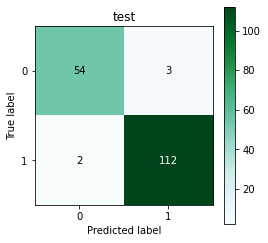

In [13]:
import scikitplot as skplt
skplt.metrics.plot_confusion_matrix(y_test, pred_test,
                  cmap=plt.cm.BuGn,
                  title = "test",
                  figsize=(4,4))
plt.show()

## 1.4 使用GridSearchCV調整參數C與gamma值來優化模型 (30%)
- 需附上訓練程式碼
- 1.4.1 SVC參數C與gamma為多少 (20%)
- 1.4.2 模型優化後準確率為多少 (10%)

In [14]:
# 載入GridSearchCV
from sklearn.model_selection import GridSearchCV

In [15]:
# GridSearchCV是建立一個dictionary來組合要測試的參數
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}

In [16]:
grid = GridSearchCV(SVC(), param_grid, cv=5, verbose=3)

In [17]:
# 利用剛剛設定的參數來找到最適合的模型
svc_model = grid.fit(X_train_std,y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] C=0.001, gamma=0.001 ............................................
[CV] ................ C=0.001, gamma=0.001, score=0.613, total=   0.0s
[CV] C=0.001, gamma=0.001 ............................................
[CV] ................ C=0.001, gamma=0.001, score=0.613, total=   0.0s
[CV] C=0.001, gamma=0.001 ............................................
[CV] ................ C=0.001, gamma=0.001, score=0.613, total=   0.0s
[CV] C=0.001, gamma=0.001 ............................................
[CV] ................ C=0.001, gamma=0.001, score=0.608, total=   0.0s
[CV] C=0.001, gamma=0.001 ............................................
[CV] ................ C=0.001, gamma=0.001, score=0.608, total=   0.0s
[CV] C=0.001, gamma=0.01 .............................................
[CV] ................. C=0.001, gamma=0.01, score=0.613, total=   0.0s
[CV] C=0.001, gamma=0.01 .............................................
[CV] ..........

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s


[CV] .................... C=0.001, gamma=1, score=0.613, total=   0.1s
[CV] C=0.001, gamma=1 ................................................
[CV] .................... C=0.001, gamma=1, score=0.613, total=   0.0s
[CV] C=0.001, gamma=1 ................................................
[CV] .................... C=0.001, gamma=1, score=0.608, total=   0.0s
[CV] C=0.001, gamma=1 ................................................
[CV] .................... C=0.001, gamma=1, score=0.608, total=   0.0s
[CV] C=0.001, gamma=10 ...............................................
[CV] ................... C=0.001, gamma=10, score=0.613, total=   0.0s
[CV] C=0.001, gamma=10 ...............................................
[CV] ................... C=0.001, gamma=10, score=0.613, total=   0.0s
[CV] C=0.001, gamma=10 ...............................................
[CV] ................... C=0.001, gamma=10, score=0.613, total=   0.0s
[CV] C=0.001, gamma=10 ...............................................
[CV] .

[Parallel(n_jobs=1)]: Done 180 out of 180 | elapsed:    2.3s finished


In [18]:
# 顯示最佳estimator參數
grid.best_estimator_

SVC(C=100, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma=0.001, kernel='rbf',
    max_iter=-1, probability=False, random_state=None, shrinking=True,
    tol=0.001, verbose=False)

In [19]:
# 利用剛剛的最佳參考再重新預測測試組
grid_pred_test = grid.predict(X_test_std)

In [20]:
mse = mean_squared_error(y_test, grid_pred_test)
r2 = r2_score(y_test, grid_pred_test)

print("mean_squared_error(testing): {0:.4f}".format(mse))
print("r2_score(testing): {0:.4f}".format(r2))

mean_squared_error(testing): 0.0117
r2_score(testing): 0.9474


In [21]:
print("SVC參數:", grid.best_params_)
print("SVC參數優化後準確率: {0:.4f}".format(r2))

SVC參數: {'C': 100, 'gamma': 0.001}
SVC參數優化後準確率: 0.9474


## 第二大題

 * 使用糖尿病資料集
 * 使用SVR : Support Vector Regression方法 
 * Target : 一年後患疾病的定量指標
 * 資料切分 train: test = 7:3

### *   載入套件與資料集



In [38]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [39]:
# 取得Scikit Learn上的糖尿病資料集
diabetes = datasets.load_diabetes()
diabetes

{'DESCR': '.. _diabetes_dataset:\n\nDiabetes dataset\n----------------\n\nTen baseline variables, age, sex, body mass index, average blood\npressure, and six blood serum measurements were obtained for each of n =\n442 diabetes patients, as well as the response of interest, a\nquantitative measure of disease progression one year after baseline.\n\n**Data Set Characteristics:**\n\n  :Number of Instances: 442\n\n  :Number of Attributes: First 10 columns are numeric predictive values\n\n  :Target: Column 11 is a quantitative measure of disease progression one year after baseline\n\n  :Attribute Information:\n      - Age\n      - Sex\n      - Body mass index\n      - Average blood pressure\n      - S1\n      - S2\n      - S3\n      - S4\n      - S5\n      - S6\n\nNote: Each of these 10 feature variables have been mean centered and scaled by the standard deviation times `n_samples` (i.e. the sum of squares of each column totals 1).\n\nSource URL:\nhttps://www4.stat.ncsu.edu/~boos/var.select/

### *   整理資料

In [40]:
X = pd.DataFrame(diabetes['data'],columns = diabetes['feature_names'])
y = pd.DataFrame(diabetes['target'],columns = ['target'])

In [41]:
print(X.isnull().sum())
print(y.isnull().sum())

age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64
target    0
dtype: int64


### *   切分訓練/測試集

In [42]:
y = y['target'].values

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)

### *  正規化 

In [44]:
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

## 2.1 自行調整參數或篩選特徵使r2_score高於0.45 (30%)

### *   調整參數

In [45]:
# 載入GridSearchCV
from sklearn.model_selection import GridSearchCV

In [46]:
# GridSearchCV是建立一個dictionary來組合要測試的參數
param_grid = {'C':[1,10,100,1000,2000],
        'gamma':[100,10,1,0.1,0.01,0.001,0.0001]}

In [47]:
grid = GridSearchCV(SVR(),param_grid,verbose=3)

### *   訓練模型

In [48]:
# 利用剛剛設定的參數來找到最適合的模型
svr_model = grid.fit(X_train_std,y_train)

Fitting 5 folds for each of 35 candidates, totalling 175 fits
[CV] C=1, gamma=100 ..................................................
[CV] ..................... C=1, gamma=100, score=-0.002, total=   0.0s
[CV] C=1, gamma=100 ..................................................
[CV] ..................... C=1, gamma=100, score=-0.000, total=   0.0s
[CV] C=1, gamma=100 ..................................................
[CV] ..................... C=1, gamma=100, score=-0.315, total=   0.0s
[CV] C=1, gamma=100 ..................................................
[CV] ..................... C=1, gamma=100, score=-0.009, total=   0.0s
[CV] C=1, gamma=100 ..................................................
[CV] ..................... C=1, gamma=100, score=-0.054, total=   0.0s
[CV] C=1, gamma=10 ...................................................
[CV] ...................... C=1, gamma=10, score=-0.002, total=   0.0s
[CV] C=1, gamma=10 ...................................................
[CV] ..........

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s


[CV] .................... C=1, gamma=0.01, score=-0.164, total=   0.0s
[CV] C=1, gamma=0.01 .................................................
[CV] ..................... C=1, gamma=0.01, score=0.103, total=   0.0s
[CV] C=1, gamma=0.01 .................................................
[CV] ..................... C=1, gamma=0.01, score=0.070, total=   0.0s
[CV] C=1, gamma=0.001 ................................................
[CV] .................... C=1, gamma=0.001, score=0.015, total=   0.0s
[CV] C=1, gamma=0.001 ................................................
[CV] .................... C=1, gamma=0.001, score=0.015, total=   0.0s
[CV] C=1, gamma=0.001 ................................................
[CV] ................... C=1, gamma=0.001, score=-0.305, total=   0.0s
[CV] C=1, gamma=0.001 ................................................
[CV] .................... C=1, gamma=0.001, score=0.006, total=   0.0s
[CV] C=1, gamma=0.001 ................................................
[CV] .

[Parallel(n_jobs=1)]: Done 175 out of 175 | elapsed:    2.5s finished


In [49]:
# 顯示最佳estimator參數
grid.best_estimator_

SVR(C=100, cache_size=200, coef0=0.0, degree=3, epsilon=0.1, gamma=0.01,
    kernel='rbf', max_iter=-1, shrinking=True, tol=0.001, verbose=False)

### *   預測結果

In [50]:
# 利用剛剛的最佳參考再重新預測測試組
grid_pred_test = grid.predict(X_test_std)

In [51]:
mse = mean_squared_error(y_test, grid_pred_test)
r2 = r2_score(y_test, grid_pred_test)

print("mean_squared_error(testing): {0:.4f}".format(mse))
print("r2_score(testing): {0:.4f}".format(r2))

mean_squared_error(testing): 2954.8032
r2_score(testing): 0.4953


## 2.2 畫出測試集y_true與y_pred折線圖 (10%) 
- 需有X座標軸名稱、Y座標軸名稱、標題與圖例

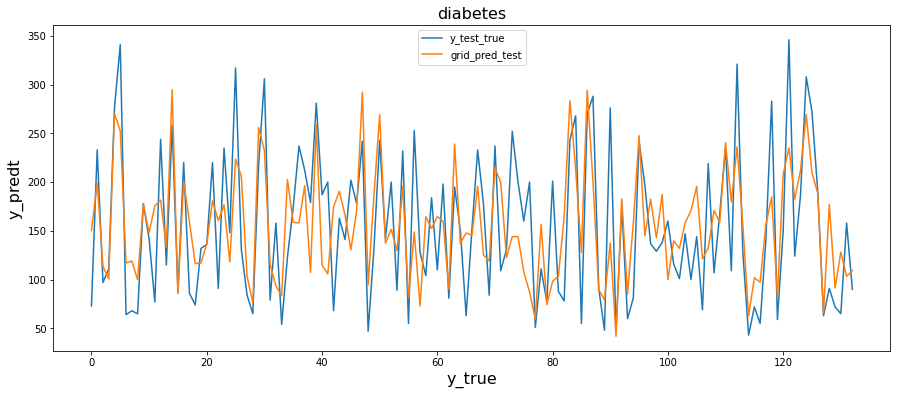

In [53]:
plt.figure(figsize=(15, 6))
plt.plot(y_test)
plt.plot(grid_pred_test)
plt.legend(['y_test_true', 'grid_pred_test'], loc='best')
plt.title("diabetes", size = 16)
plt.xlabel("y_true", size = 16)
plt.ylabel("y_predt", size = 16)
plt.show()